# HumanEval performance and capture quality

This notebook reads the combined SpaceTimePy v2 benchmark results.

In [6]:
import json
from pathlib import Path

import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

results = json.loads(Path("results/humaneval_results.json").read_text())
len(results)

164

In [7]:
rows = []
for problem in results:
    for variant in ("reference", "function", "line"):
        run = problem.get(variant, {})
        for duration_ns in run.get("internal_times_ns", []):
            rows.append(
                {
                    "problem_index": problem["problem_index"],
                    "variant": variant,
                    "duration_ms": duration_ns / 1_000_000,
                }
            )
timings = pd.DataFrame(rows)
timings.groupby("variant")["duration_ms"].describe()

,count,mean,std,min,25%,50%,75%,max
variant,,,,,,,,
function,123095.0,1.073350,13.860363,0.071573,0.248226,0.396577,0.634420,1687.652078
line,120048.0,10.306945,73.302388,0.125309,0.527062,0.934356,2.966578,18366.765387
reference,123095.0,0.149908,5.426804,0.000072,0.000468,0.000961,0.002204,616.880242


In [8]:
problem_means = (
    timings.groupby(["problem_index", "variant"], as_index=False)["duration_ms"]
    .mean()
    .pivot(index="problem_index", columns="variant", values="duration_ms")
)
overhead = problem_means.assign(
    function_overhead=lambda frame: frame["function"] / frame["reference"],
    line_overhead=lambda frame: frame["line"] / frame["reference"],
)
overhead[["function_overhead", "line_overhead"]].describe()

variant,function_overhead,line_overhead
count,163.000000,154.000000
mean,1058.698230,5910.582619
std,1588.103044,7174.844267
min,0.736692,1.129064
25%,210.496668,814.653650
50%,520.271352,3345.215220
75%,1207.398553,7569.560411
max,9185.779036,34536.378165


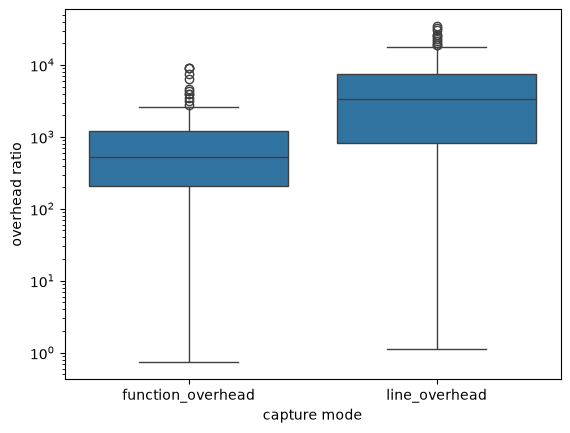

In [9]:
plot_data = overhead[["function_overhead", "line_overhead"]].melt(
    var_name="capture mode", value_name="overhead ratio"
)
sns.boxplot(data=plot_data, x="capture mode", y="overhead ratio")
plt.yscale("log")
plt.show()

In [10]:
quality = pd.DataFrame(
    [
        {"problem_index": problem["problem_index"], **problem["quality"]["quality"]}
        for problem in results
        if "quality" in problem
    ]
)
quality[["captured_call_count", "replayed_call_count", "failure_count"]].sum()

captured_call_count    1006
replayed_call_count    1006
failure_count             0
dtype: int64